Data source: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

**1. DATA PREPROCESSING**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

100%|██████████| 612M/612M [00:43<00:00, 14.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

In [4]:
IMG_SIZE = (32, 32)
np.random.seed(42)
torch.manual_seed(42)

CLASS_MAP = {
    0:'speed_limit', 1:'speed_limit', 2:'speed_limit', 3:'speed_limit', 4:'speed_limit', 5:'speed_limit', 7:'speed_limit', 8:'speed_limit',
    13:'yield',
    14:'stop',
    17:'no_entry',
    33:'one_way', 34:'one_way', 35:'one_way', 36:'one_way', 37:'one_way', 38:'one_way', 39:'one_way'}

labels = ['speed_limit', 'yield', 'stop', 'no_entry', 'one_way']
label_to_IDX = {name: i for i, name in enumerate(labels)}

In [5]:
df_train_raw = pd.read_csv(os.path.join(path, 'Train.csv'))

def filter_and_label(df, root):
    rows = []
    for _, row in df.iterrows():
        cid = int(row['ClassId'])
        if cid in CLASS_MAP:
            rows.append({'filepath':os.path.join(root,row['Path']), 'label':CLASS_MAP[cid],'label_idx': label_to_IDX[CLASS_MAP[cid]]})
    return pd.DataFrame(rows)

df = filter_and_label(df_train_raw, path)
print(f"Filtered dataset: {len(df):,} images")
df['label'].value_counts()

Filtered dataset: 22,109 images


,count
label,
speed_limit,12780
one_way,5279
yield,2160
no_entry,1110
stop,780


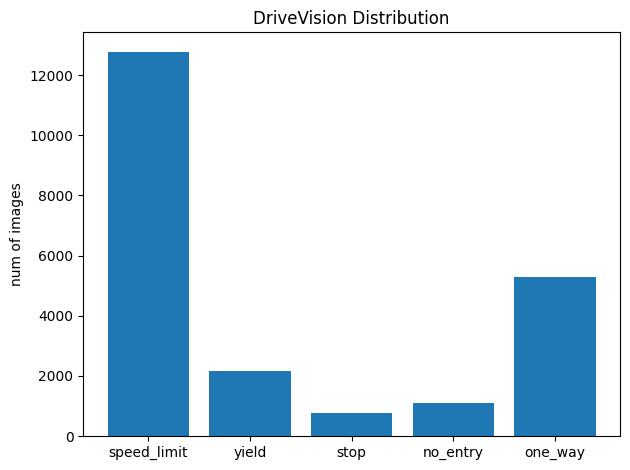

In [6]:
counts = df['label'].value_counts().reindex(labels)

fig, ax = plt.subplots()
bars = ax.bar(labels, counts.values)
ax.set_title('DriveVision Distribution')
ax.set_ylabel('num of images')
plt.tight_layout()
plt.show()

In [7]:
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['label'])

print('Train:', len(df_train))
print('Val:', len(df_val))
print('Test:', len(df_test))

Train: 15476
Val: 3316
Test: 3317


In [8]:
mu = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mu, std)
])

In [9]:
class TrafficSignDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, row['label_idx']

train_loader = DataLoader(TrafficSignDataset(df_train, transform), batch_size=64, shuffle=True)
val_loader = DataLoader(TrafficSignDataset(df_val,   transform),  batch_size=64, shuffle=False)
test_loader = DataLoader(TrafficSignDataset(df_test,  transform),  batch_size=64, shuffle=False)

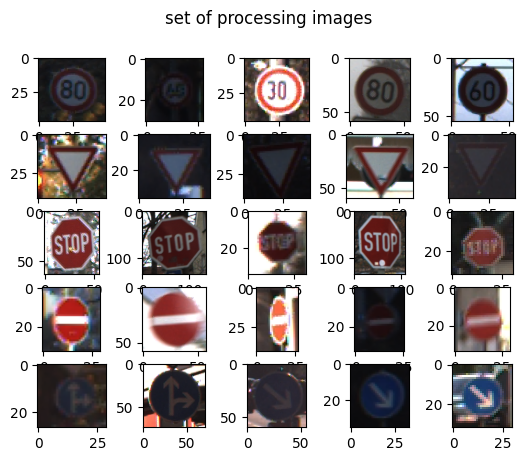

In [10]:
fig, axes = plt.subplots(5, 5)
fig.suptitle('set of processing images')

for row_idx, label in enumerate(labels):
    subset = df_train[df_train['label'] == label].sample(5, random_state=42)
    for col_idx, (_, img_row) in enumerate(subset.iterrows()):
        img = Image.open(img_row['filepath']).convert('RGB') #for good measure
        ax  = axes[row_idx][col_idx]
        ax.imshow(img)

plt.show()

In [11]:
summary = pd.DataFrame({
    'Class':labels,
    'Total':[counts[l] for l in labels],
    'Train':[len(df_train[df_train['label']==l]) for l in labels],
    'Val':[len(df_val[df_val['label']==l]) for l in labels],
    'Test':[len(df_test[df_test['label']==l]) for l in labels],
})
summary

,Class,Total,Train,Val,Test
0,speed_limit,12780,8946,1917,1917
1,yield,2160,1512,324,324
2,stop,780,546,117,117
3,no_entry,1110,777,166,167
4,one_way,5279,3695,792,792


**2. BASELINE MODEL**

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [13]:
def load_flat_images(df):
    X, y = [], []
    for _, row in df.iterrows():
        img = Image.open(row['filepath']).convert('RGB').resize(IMG_SIZE)
        X.append(np.array(img).flatten() / 255.0)  # flatten to 1D, normalize
        y.append(row['label_idx'])
    return np.array(X), np.array(y)

X_train, y_train = load_flat_images(df_train)
X_val, y_val = load_flat_images(df_val)

In [14]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

SVC(random_state=42)

In [15]:
y_pred = svm.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print('svm validation accuracy:', acc)

svm validation accuracy: 0.9843184559710495


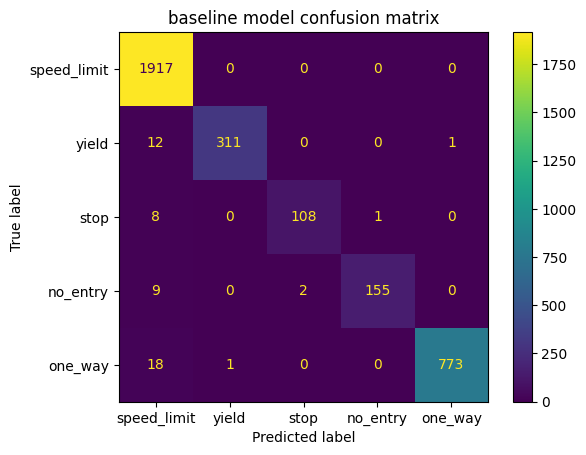

In [16]:
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title('baseline model confusion matrix')
plt.show()

**3. Primary Model**

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
class DriveVisionCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 5)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = DriveVisionCNN(num_classes=5).to(device)

In [20]:
class_counts = torch.tensor([12780, 2160, 780, 1110, 5279], dtype=torch.float)
class_weights = (1.0 / class_counts)
class_weights = (class_weights / class_weights.sum() * len(class_counts)).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [21]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == lbls).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == lbls).sum().item()
            total += imgs.size(0)
    return running_loss / total, correct / total

In [22]:
NUM_EPOCHS = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}'
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}'
          f'Val Loss: {va_loss:.4f}  Acc: {va_acc:.4f}')

Epoch 01/15Train Loss: 0.2348  Acc: 0.9109Val Loss: 0.0083  Acc: 0.9994
Epoch 02/15Train Loss: 0.0143  Acc: 0.9955Val Loss: 0.0065  Acc: 0.9976
Epoch 03/15Train Loss: 0.0197  Acc: 0.9937Val Loss: 0.0029  Acc: 0.9982
Epoch 04/15Train Loss: 0.0033  Acc: 0.9990Val Loss: 0.0103  Acc: 0.9979
Epoch 05/15Train Loss: 0.0095  Acc: 0.9961Val Loss: 0.0122  Acc: 0.9991
Epoch 06/15Train Loss: 0.0030  Acc: 0.9988Val Loss: 0.0068  Acc: 0.9991
Epoch 07/15Train Loss: 0.0142  Acc: 0.9970Val Loss: 0.0024  Acc: 0.9991
Epoch 08/15Train Loss: 0.0025  Acc: 0.9992Val Loss: 0.0011  Acc: 0.9997
Epoch 09/15Train Loss: 0.0023  Acc: 0.9991Val Loss: 0.0005  Acc: 1.0000
Epoch 10/15Train Loss: 0.0030  Acc: 0.9985Val Loss: 0.0032  Acc: 0.9991
Epoch 11/15Train Loss: 0.0018  Acc: 0.9991Val Loss: 0.0003  Acc: 0.9994
Epoch 12/15Train Loss: 0.0009  Acc: 0.9996Val Loss: 0.0002  Acc: 1.0000
Epoch 13/15Train Loss: 0.0009  Acc: 0.9997Val Loss: 0.0004  Acc: 1.0000
Epoch 14/15Train Loss: 0.0007  Acc: 0.9999Val Loss: 0.0005  Acc:

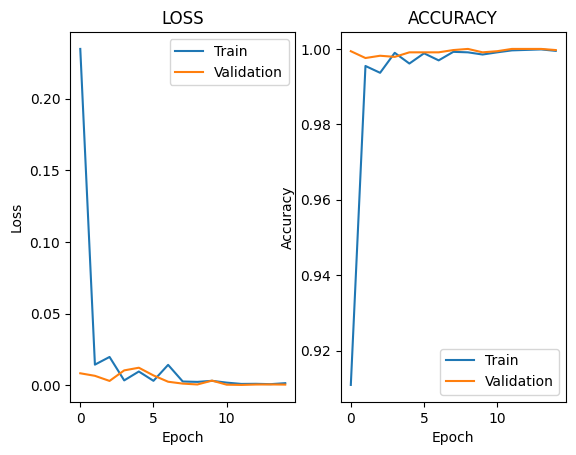

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(train_losses, label='Train')
ax1.plot(val_losses, label='Validation')
ax1.set_title('LOSS')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train')
ax2.plot(val_accs, label='Validation')
ax2.set_title('ACCURACY')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend()
plt.show()

cnn test Accuracy: 0.9990955682845946


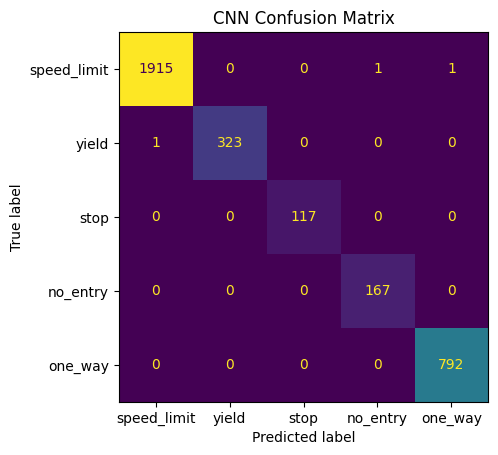

In [24]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print('cnn test Accuracy:', test_acc)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots()
disp.plot(ax=ax, colorbar=False)
ax.set_title('CNN Confusion Matrix')
plt.show()

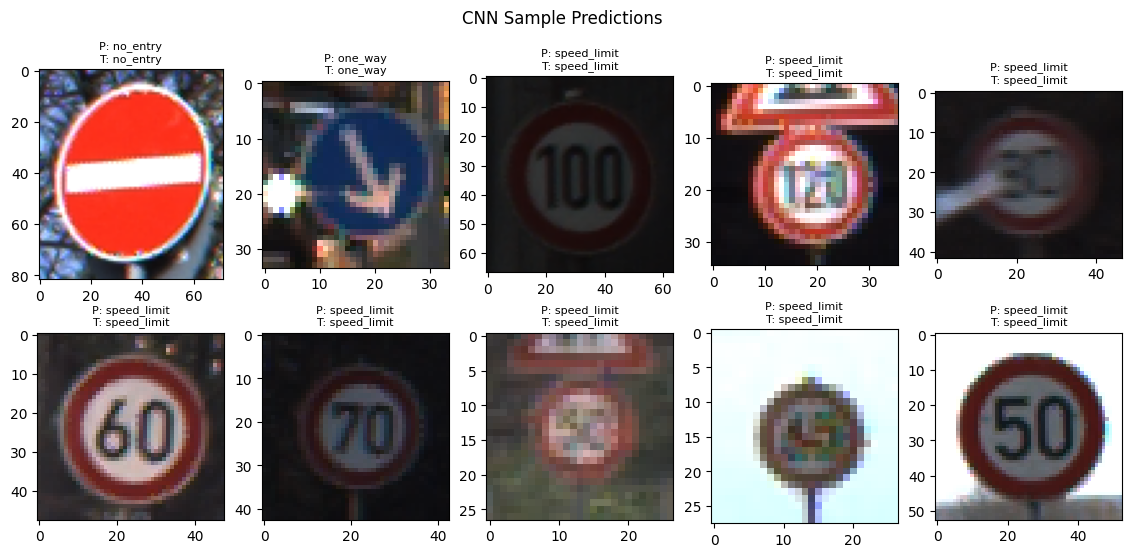

In [25]:
label_names = ['speed_limit', 'yield', 'stop', 'no_entry', 'one_way']
sample_df = df_test.sample(10, random_state=7).reset_index(drop=True)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CNN Sample Predictions')

model.eval()
with torch.no_grad():
    for i, (_, row) in enumerate(sample_df.iterrows()):
        img_pil = Image.open(row['filepath']).convert('RGB')
        img_tensor = transform(img_pil).unsqueeze(0).to(device)
        pred_idx = model(img_tensor).argmax(1).item()
        true_idx = row['label_idx']

        ax = axes[i // 5][i % 5]
        ax.imshow(img_pil)
        ax.set_title(f"P: {label_names[pred_idx]}\nT: {label_names[true_idx]}", fontsize=8)

plt.show()

**4. Testing the Model**

In [26]:
!pip install pillow-heif -q
from pillow_heif import register_heif_opener
register_heif_opener() # need to convert iphone .heic images

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 129.5 MB/s eta 0:00:00


In [27]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from collections import defaultdict

ONTARIO_DIR = Path('/content/drive/MyDrive/ontario_signs')

ontario_data = []
for label in labels:
    folder = ONTARIO_DIR / label
    for img_path in sorted(folder.glob('*.HEIC')):
        ontario_data.append({'filepath': str(img_path), 'label': label, 'label_idx': label_to_IDX[label]})

ontario_df = pd.DataFrame(ontario_data)
print(ontario_df['label'].value_counts())

Mounted at /content/drive
label
no_entry       8
speed_limit    6
yield          6
stop           3
one_way        2
Name: count, dtype: int64


ontario accuracy:  0.44


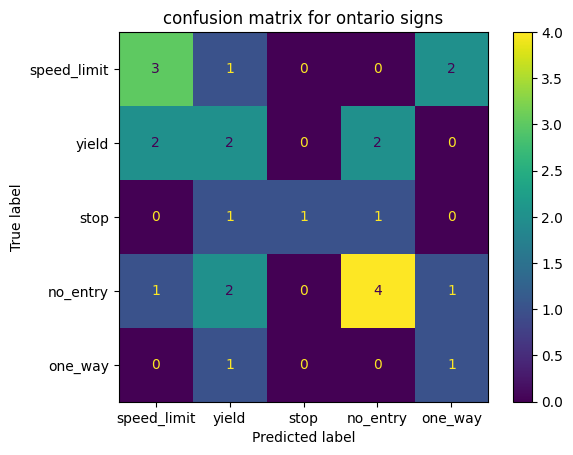

In [28]:
model.eval()
ontario_preds, ontario_true = [], []

with torch.no_grad():
    for _, row in ontario_df.iterrows():
        img_tensor = transform(Image.open(row['filepath']).convert('RGB')).unsqueeze(0).to(device)
        ontario_preds.append(model(img_tensor).argmax(1).item())
        ontario_true.append(row['label_idx'])

ontario_acc = accuracy_score(ontario_true, ontario_preds)
print('ontario accuracy: ',  int(ontario_acc*len(ontario_df))/len(ontario_df))

disp = ConfusionMatrixDisplay(confusion_matrix(ontario_true, ontario_preds, labels=list(range(5))), display_labels=labels)
disp.plot()
plt.title('confusion matrix for ontario signs')
plt.show()